### Imports

In [2]:
import numpy as np
import scipy  
import astropy
import matplotlib.pyplot as plt
from astropy.io import fits
import glob

### Measuring the Bias and Read Noise

In [3]:
files = sorted(glob.glob('bias_*.fits'))  

means = []
stds = []
for f in files:
    data = fits.getdata(f).astype(float)
    means.append(np.mean(data))
    stds.append(np.std(data))

means = np.array(means)
stds = np.array(stds)

print("Bias level (mean of means):", np.mean(means))
print("Read noise (mean of stds):", np.mean(stds))
print("Std of means (frame-to-frame bias stability):", np.std(means))
print("Std of stds (frame-to-frame noise consistency):", np.std(stds))

Bias level (mean of means): nan
Read noise (mean of stds): nan
Std of means (frame-to-frame bias stability): nan
Std of stds (frame-to-frame noise consistency): nan


/opt/anaconda3/envs/dark_matter/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/dark_matter/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/dark_matter/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/dark_matter/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/dark_matter/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### Linearity and Saturation

### Cosmic Rays

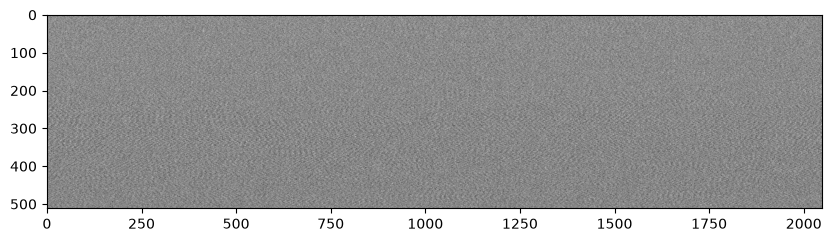

In [11]:
data = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/AndorCCD-CosmicRays/Dark-001_bias.fit"
plt.figure(figsize=(10, 8))
plt.imshow(fits.getdata(data), cmap='gray')

In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import importlib

plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "axes.unicode_minus": False,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{amsmath}",
})

In [30]:
import cosmic_rays as cs
importlib.reload(cs)

stack, files = cs.load_stack("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/AndorCCD-CosmicRays/")
ny, nx = stack.shape[1], stack.shape[2]

hot_mask, median_map = cs.find_hot_pixels(stack, nsigma=cs.HOT_PIXEL_NSIGMA)
events_per_frame = cs.find_cosmic_rays(stack, median_map, hot_mask, nsigma=cs.COSMIC_RAY_NSIGMA)

cs.compute_rate(events_per_frame, cs.EXPTIME_S, cs.PIXEL_PITCH_UM, nx, ny)

Loaded 24 frames, shape (24, 512, 2048)
Median map level: 156.0 DN, robust sigma: 0.74 DN, threshold: 161.9 DN
Hot pixels found: 143
Residual robust sigma: 8.90 DN, cosmic-ray threshold: 44.5 DN
Cosmic ray candidates per frame: [      0      76       0      77       6       0 1048433       0      79
      57     120      70      92      70      95     119      94      76
     120      63      57      64     164      74]
Mean events/frame: 43750.25

Total cosmic ray events: 1050006
Total exposure time: 240.0 min
Chip area: 57.42 mm^2
Cosmic ray rate: 76.1934 events/min/mm^2


np.float64(76.1933706379703)